In [52]:
#Loading datasets and importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

data = pd.read_csv("../datasets/yield_df.csv")
data.head()


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [53]:
#checking the dataset shape
data.shape

(28242, 8)

In [54]:
#Data cleaning
#checking dataset information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB


In [87]:
#checking the missing values
data.isnull().sum()

Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

In [86]:
#removing unnamed index column
data = data.drop(columns=["Unnamed: 0"])

KeyError: "['Unnamed: 0'] not found in axis"

In [76]:
#showing now datasets columns after removing unwanted column i.e unnamed
data.columns

Index(['Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year',
       'pesticides_tonnes', 'avg_temp'],
      dtype='str')

In [81]:
# #check the duplicate row values 
data.duplicated().sum()

np.int64(2310)

In [85]:
#dataset statistics

data.describe()

,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,4.420898,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,2.635337,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,3.000000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,4.000000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,7.000000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,9.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


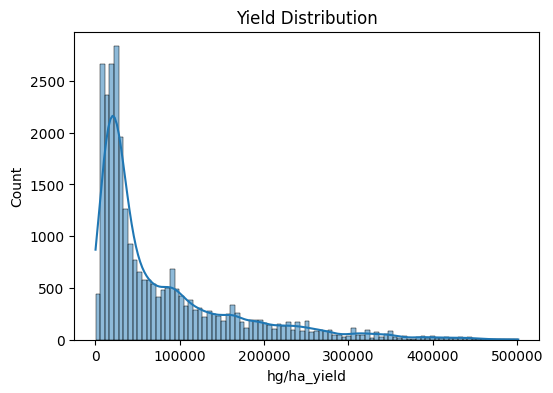

In [82]:
#EDA - Exploratory Data Analysis
#Yield Distribution

plt.figure(figsize=(6,4))
sns.histplot(data['hg/ha_yield'], kde=True)
plt.title("Yield Distribution")
plt.show()


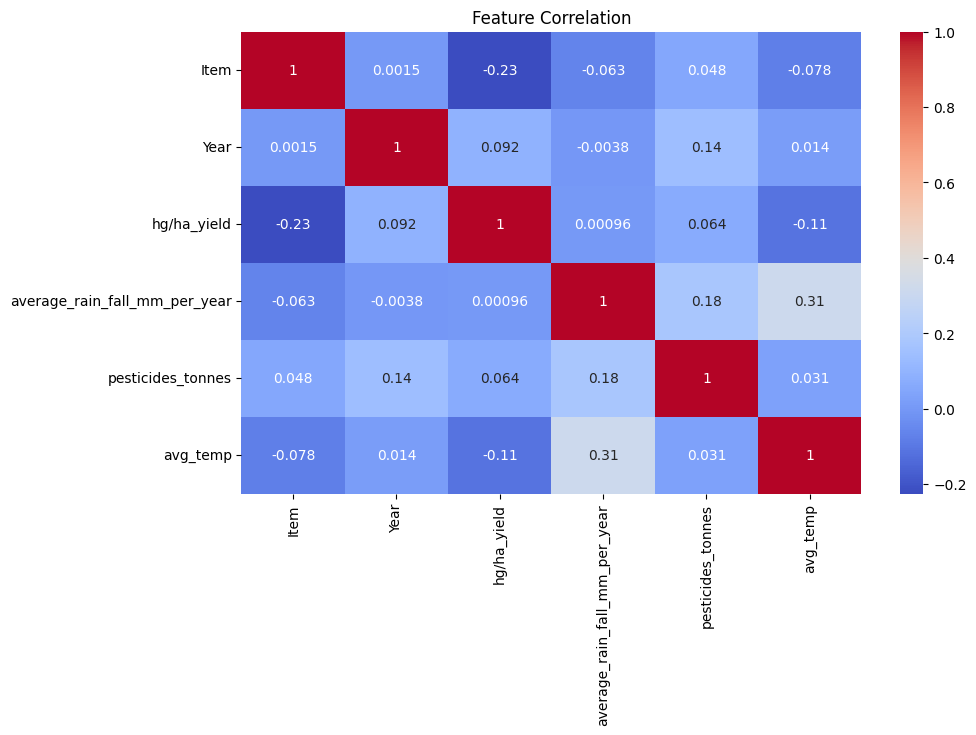

In [83]:
#Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

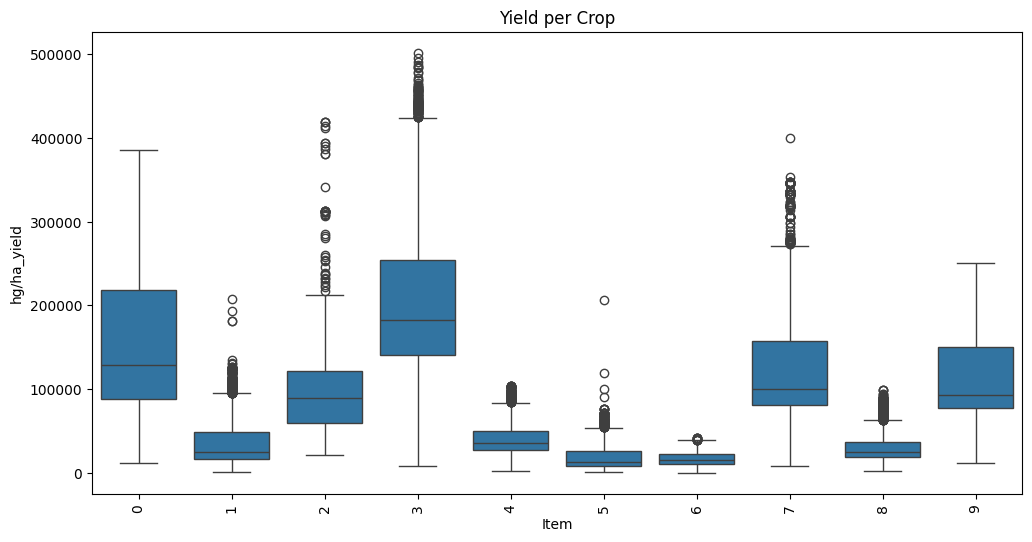

In [84]:
#crop vs yield
# plt.figure(figsize=(8,5))
# sns.boxplot(x="Item", y="hg/ha_yield", data = data)
# plt.title("Yield per Crop")
# plt.show()


plt.figure(figsize=(12,6))
sns.boxplot(x="Item", y="hg/ha_yield", data=data)

plt.xticks(rotation=90)
plt.title("Yield per Crop")
plt.show()

In [67]:
# Features selection
#Encode crop column i.e Item
encoder = LabelEncoder()

data["Item"] = encoder.fit_transform(data["Item"])

In [ ]:
#separate features and target
X = data.drop("hg/ha_yield", axis=1)
y = data["hg/ha_yield"]

In [68]:
#Train and Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [69]:
#Train multiple models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=200)
}

results = {}

In [70]:
#Train and Evaluation of models
for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

results_df = pd.DataFrame(results).T
results_df

ValueError: could not convert string to float: 'Cameroon'

In [ ]:
#comaparison and evaluation
results_df.sort_values(by="R2 Score", ascending=False)

NameError: name 'results_df' is not defined

In [41]:
#features importances
rf_model = models["Random Forest"]

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance")
plt.show()

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [42]:
best_model = models["Random Forest"]

joblib.dump(best_model, "../ml_models/yield_prediction/yield_model.pkl")

print("Model saved successfully!")

Model saved successfully!
